SIMULADOR ACTUARIAL - CAJA FISCAL PARAGUAY
BALANCE 2023 - DATOS REALES
Ingresos totales: Gs. 3,621,049M ($498M USD)
Gastos totales:   Gs. 4,761,041M ($654M USD)
Resultado 2023:   Gs. -1,139,992M ($-157M USD)
Patrimonio neto:  $741M USD (Gs. 5,392,998,000,000M)
🚨 DÉFICIT OPERATIVO 2023: Gs. 1,139,992M

Por sector:
--------------------------------------------------------------------------------
Sector                    Ingresos (M Gs) Gastos (M Gs)   Resultado (M Gs)
--------------------------------------------------------------------------------
Administración Pública          1,603,068         870,743         732,325
Magistrados Judiciales            131,326         108,080          23,246
Magisterio Nacional             1,176,179       1,913,773        -737,594
Docentes Universitarios           161,183         164,802          -3,619
Fuerzas Armadas                   209,040         787,957        -578,917
Fuerzas Policiales                340,251         915,686        -575,435

ANÁ

C:\Users\yoda\AppData\Local\Temp\ipykernel_22004\2829989498.py:325: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(nombres, rotation=15, ha='right')


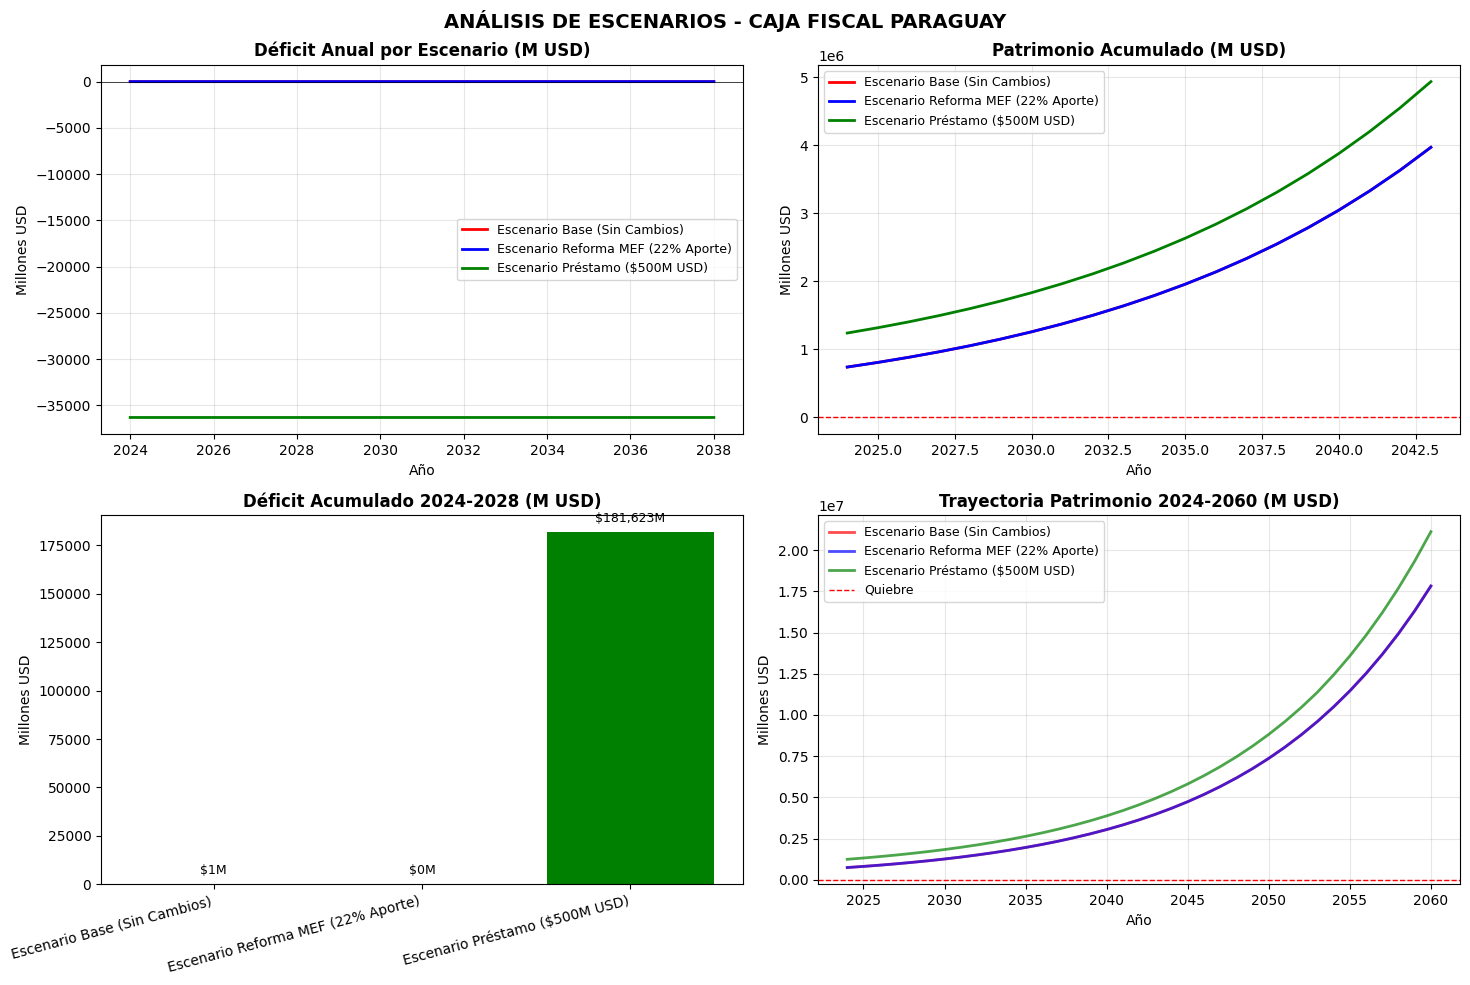


✓ Reporte generado: reporte_jubilacion_20260204_152906.xlsx

ANÁLISIS COMPLETADO


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

class SistemaJubilacionSimplificado:
    """Sistema simplificado con datos reales de Paraguay 2023"""
    
    def __init__(self):
        self.tasa_cambio = 7278  # Gs/USD promedio 2023
        self.año_base = 2023
        self.horizonte = 2060
        
        # Datos reales 2023 (en millones de guaraníes)
        self.ingresos_2023 = {
            'Administración Pública': 1603068,
            'Magistrados Judiciales': 131326,
            'Magisterio Nacional': 1176179,
            'Docentes Universitarios': 161183,
            'Fuerzas Armadas': 209040,
            'Fuerzas Policiales': 340251,
            'TOTAL': 3621049
        }
        
        # Gastos reales 2023 (en millones de guaraníes)
        self.gastos_2023 = {
            'Administración Pública': 870743,
            'Magistrados Judiciales': 108080,
            'Magisterio Nacional': 1913773,
            'Docentes Universitarios': 164802,
            'Fuerzas Armadas': 787957,
            'Fuerzas Policiales': 915686,
            'TOTAL': 4761041
        }
        
        # Número de funcionarios diciembre 2025 (aproximado)
        self.funcionarios_2025 = {
            'Administración Pública': 107073,
            'Magistrados Judiciales': 9013,
            'Magisterio Nacional': 102371,
            'Docentes Universitarios': 12975,
            'Fuerzas Armadas': 18331,
            'Fuerzas Policiales': 35053
        }
        
        # Premisas actuariales (del informe MEF)
        self.premisas = {
            'tasa_aporte_base': 0.16,  # 16%
            'tasa_aporte_reforma': 0.22,  # 22%
            'tasa_interes_real': 0.050355,  # 5.0355%
            'inflacion': 0.04,  # 4%
            'crecimiento_salarial_real': 0.01,  # 1%
            'crecimiento_aportantes': 0.0485,  # 4.85%
            'crecimiento_beneficios': 0.0377,  # 3.77%
            'tasa_rendimiento_nominal': 0.092369,  # 9.2369%
        }
        
        # Patrimonio inicial (solo Programa Civil)
        self.patrimonio_inicial_usd = 741_000_000  # USD
        self.patrimonio_inicial_gs = self.patrimonio_inicial_usd * self.tasa_cambio
    
    def calcular_balance_2023(self):
        """Calcula el balance inicial 2023"""
        resultado_2023 = self.ingresos_2023['TOTAL'] - self.gastos_2023['TOTAL']
        
        print("="*80)
        print("BALANCE 2023 - DATOS REALES")
        print("="*80)
        print(f"Ingresos totales: Gs. {self.ingresos_2023['TOTAL']:,.0f}M (${self.ingresos_2023['TOTAL']/self.tasa_cambio:,.0f}M USD)")
        print(f"Gastos totales:   Gs. {self.gastos_2023['TOTAL']:,.0f}M (${self.gastos_2023['TOTAL']/self.tasa_cambio:,.0f}M USD)")
        print(f"Resultado 2023:   Gs. {resultado_2023:,.0f}M (${resultado_2023/self.tasa_cambio:,.0f}M USD)")
        print(f"Patrimonio neto:  ${self.patrimonio_inicial_usd/1_000_000:,.0f}M USD (Gs. {self.patrimonio_inicial_gs:,.0f}M)")
        
        if resultado_2023 < 0:
            print(f"🚨 DÉFICIT OPERATIVO 2023: Gs. {abs(resultado_2023):,.0f}M")
        
        print("\nPor sector:")
        print("-"*80)
        print(f"{'Sector':<25} {'Ingresos (M Gs)':<15} {'Gastos (M Gs)':<15} {'Resultado (M Gs)':<15}")
        print("-"*80)
        
        for sector in ['Administración Pública', 'Magistrados Judiciales', 'Magisterio Nacional',
                      'Docentes Universitarios', 'Fuerzas Armadas', 'Fuerzas Policiales']:
            ing = self.ingresos_2023[sector]
            gas = self.gastos_2023[sector]
            res = ing - gas
            print(f"{sector:<25} {ing:>15,.0f} {gas:>15,.0f} {res:>15,.0f}")
        
        return resultado_2023
    
    def simular_escenario_base(self):
        """Escenario 1: Sin cambios"""
        años = list(range(2024, self.horizonte + 1))
        n_años = len(años)
        
        # Inicializar arrays
        ingresos = np.zeros(n_años)
        gastos = np.zeros(n_años)
        resultados = np.zeros(n_años)
        patrimonio = np.zeros(n_años)
        deficit_acum = np.zeros(n_años)
        
        # Valores iniciales
        ingresos[0] = self.ingresos_2023['TOTAL']
        gastos[0] = self.gastos_2023['TOTAL']
        resultados[0] = ingresos[0] - gastos[0]
        patrimonio[0] = self.patrimonio_inicial_gs
        deficit_acum[0] = resultados[0] if resultados[0] < 0 else 0
        
        # Tasas de crecimiento (nominales)
        tasa_crecimiento_ingresos = (1 + self.premisas['inflacion'] + 
                                    self.premisas['crecimiento_salarial_real'] + 
                                    self.premisas['crecimiento_aportantes']) - 1
        
        tasa_crecimiento_gastos = (1 + self.premisas['inflacion'] + 
                                  self.premisas['crecimiento_beneficios']) - 1
        
        # Proyección
        for i in range(1, n_años):
            # Proyectar ingresos y gastos
            ingresos[i] = ingresos[i-1] * (1 + tasa_crecimiento_ingresos)
            gastos[i] = gastos[i-1] * (1 + tasa_crecimiento_gastos)
            resultados[i] = ingresos[i] - gastos[i]
            
            # Calcular rendimiento del patrimonio
            rendimiento = patrimonio[i-1] * self.premisas['tasa_rendimiento_nominal']
            
            # Actualizar patrimonio (no puede ser negativo)
            patrimonio[i] = max(0, patrimonio[i-1] + resultados[i] + rendimiento)
            
            # Calcular déficit acumulado
            if resultados[i] < 0:
                deficit_acum[i] = deficit_acum[i-1] + abs(resultados[i])
            else:
                deficit_acum[i] = deficit_acum[i-1]
        
        return {
            'años': años,
            'ingresos': ingresos,
            'gastos': gastos,
            'resultados': resultados,
            'patrimonio': patrimonio,
            'deficit_acumulado': deficit_acum,
            'nombre': 'Escenario Base (Sin Cambios)'
        }
    
    def simular_escenario_reforma(self):
        """Escenario 2: Reforma MEF (22% aporte, ajuste edades)"""
        base = self.simular_escenario_base()
        
        # Ajustar por reforma:
        # 1. Aumento de aportes del 16% al 22% -> factor 22/16 = 1.375
        factor_aporte = 1.375
        
        # 2. Reducción de gastos por ajuste de edades (estimado 5%)
        factor_reduccion_gastos = 0.95
        
        # Aplicar ajustes
        ingresos_ajustados = base['ingresos'] * factor_aporte
        gastos_ajustados = base['gastos'] * factor_reduccion_gastos
        resultados_ajustados = ingresos_ajustados - gastos_ajustados
        
        # Recalcular patrimonio con resultados ajustados
        patrimonio_ajustado = np.zeros_like(base['patrimonio'])
        patrimonio_ajustado[0] = base['patrimonio'][0]
        
        for i in range(1, len(base['años'])):
            rendimiento = patrimonio_ajustado[i-1] * self.premisas['tasa_rendimiento_nominal']
            patrimonio_ajustado[i] = max(0, patrimonio_ajustado[i-1] + resultados_ajustados[i] + rendimiento)
        
        return {
            'años': base['años'],
            'ingresos': ingresos_ajustados,
            'gastos': gastos_ajustados,
            'resultados': resultados_ajustados,
            'patrimonio': patrimonio_ajustado,
            'deficit_acumulado': np.cumsum(np.where(resultados_ajustados < 0, abs(resultados_ajustados), 0)),
            'nombre': 'Escenario Reforma MEF (22% Aporte)'
        }
    
    def simular_escenario_prestamo(self, monto_usd_millones=500):
        """Escenario 3: Con préstamo para capitalización"""
        base = self.simular_escenario_base()
        
        # Monto del préstamo
        monto_prestamo_gs = monto_usd_millones * 1_000_000 * self.tasa_cambio
        
        # Parámetros del préstamo (30 años, 6% interés)
        plazo = 30
        tasa_interes = 0.06
        
        # Calcular cuota anual (sistema francés)
        cuota_anual = monto_prestamo_gs * (tasa_interes * (1 + tasa_interes)**plazo) / ((1 + tasa_interes)**plazo - 1)
        
        # Aplicar préstamo
        patrimonio_con_prestamo = base['patrimonio'].copy()
        patrimonio_con_prestamo[0] += monto_prestamo_gs
        
        resultados_con_prestamo = base['resultados'].copy()
        
        # Restar servicio de deuda durante el plazo
        for i in range(min(plazo, len(base['años']))):
            resultados_con_prestamo[i] -= cuota_anual
        
        # Recalcular patrimonio con servicio de deuda
        for i in range(1, len(base['años'])):
            rendimiento = patrimonio_con_prestamo[i-1] * self.premisas['tasa_rendimiento_nominal']
            patrimonio_con_prestamo[i] = max(0, patrimonio_con_prestamo[i-1] + resultados_con_prestamo[i] + rendimiento)
        
        return {
            'años': base['años'],
            'ingresos': base['ingresos'],
            'gastos': base['gastos'],
            'resultados': resultados_con_prestamo,
            'patrimonio': patrimonio_con_prestamo,
            'deficit_acumulado': np.cumsum(np.where(resultados_con_prestamo < 0, abs(resultados_con_prestamo), 0)),
            'nombre': f'Escenario Préstamo (${monto_usd_millones}M USD)',
            'cuota_prestamo': cuota_anual,
            'plazo_prestamo': plazo
        }
    
    def analizar_escenarios(self):
        """Ejecuta y analiza los tres escenarios"""
        print("\n" + "="*80)
        print("ANÁLISIS DE ESCENARIOS 2024-2060")
        print("="*80)
        
        # Simular escenarios
        escenario1 = self.simular_escenario_base()
        escenario2 = self.simular_escenario_reforma()
        escenario3 = self.simular_escenario_prestamo(500)
        
        escenarios = [escenario1, escenario2, escenario3]
        
        # Análisis comparativo
        resultados_comparativos = []
        
        for esc in escenarios:
            # Calcular métricas clave
            deficit_5_anhos = sum(r for r in esc['resultados'][:5] if r < 0)
            deficit_total = sum(r for r in esc['resultados'] if r < 0)
            
            # Encontrar año de quiebre (patrimonio <= 0)
            año_quiebre = None
            for i, pat in enumerate(esc['patrimonio']):
                if pat <= 0 and año_quiebre is None:
                    año_quiebre = esc['años'][i]
                    break
            
            resultados_comparativos.append({
                'Escenario': esc['nombre'],
                'Déficit 5 años (M USD)': abs(deficit_5_anhos) / self.tasa_cambio / 1_000,
                'Déficit Total (M USD)': abs(deficit_total) / self.tasa_cambio / 1_000,
                'Año de Quiebre': año_quiebre if año_quiebre else '>2060',
                'Patrimonio Final (M USD)': esc['patrimonio'][-1] / self.tasa_cambio / 1_000
            })
        
        # Mostrar tabla comparativa
        df_comparativo = pd.DataFrame(resultados_comparativos)
        print("\nCOMPARACIÓN DE ESCENARIOS:")
        print("-"*80)
        print(df_comparativo.to_string(index=False))
        
        # Análisis de sensibilidad
        print("\n" + "="*80)
        print("ANÁLISIS DE SENSIBILIDAD")
        print("="*80)
        
        base_deficit = abs(sum(r for r in escenario1['resultados'] if r < 0)) / self.tasa_cambio / 1_000
        
        for esc in resultados_comparativos:
            if esc['Escenario'] != 'Escenario Base (Sin Cambios)':
                mejora = base_deficit - esc['Déficit Total (M USD)']
                mejora_pct = (mejora / base_deficit * 100) if base_deficit > 0 else 0
                print(f"{esc['Escenario']}: Reduce déficit en ${mejora:,.0f}M USD ({mejora_pct:.1f}%)")
        
        return escenarios, df_comparativo
    
    def visualizar_resultados(self, escenarios):
        """Genera gráficos comparativos"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        colores = ['red', 'blue', 'green']
        nombres = [e['nombre'] for e in escenarios]
        
        # 1. Déficit anual (primeros 15 años)
        ax1 = axes[0, 0]
        for i, esc in enumerate(escenarios):
            años = esc['años'][:15]
            deficit_anual = [r / self.tasa_cambio / 1_000 for r in esc['resultados'][:15]]
            ax1.plot(años, deficit_anual, label=nombres[i], color=colores[i], linewidth=2)
        
        ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax1.set_title('Déficit Anual por Escenario (M USD)', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Año')
        ax1.set_ylabel('Millones USD')
        ax1.legend(fontsize=9)
        ax1.grid(True, alpha=0.3)
        
        # 2. Patrimonio acumulado
        ax2 = axes[0, 1]
        for i, esc in enumerate(escenarios):
            años = esc['años'][:20]
            patrimonio = [p / self.tasa_cambio / 1_000 for p in esc['patrimonio'][:20]]
            ax2.plot(años, patrimonio, label=nombres[i], color=colores[i], linewidth=2)
        
        ax2.axhline(y=0, color='red', linestyle='--', linewidth=1)
        ax2.set_title('Patrimonio Acumulado (M USD)', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Año')
        ax2.set_ylabel('Millones USD')
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3)
        
        # 3. Comparación déficit 2024-2028
        ax3 = axes[1, 0]
        deficit_5_anhos = []
        
        for esc in escenarios:
            deficit = sum(r for r in esc['resultados'][:5] if r < 0)
            deficit_5_anhos.append(abs(deficit) / self.tasa_cambio / 1_000)
        
        bars = ax3.bar(nombres, deficit_5_anhos, color=colores)
        ax3.set_title('Déficit Acumulado 2024-2028 (M USD)', fontsize=12, fontweight='bold')
        ax3.set_ylabel('Millones USD')
        ax3.set_xticklabels(nombres, rotation=15, ha='right')
        
        for bar, valor in zip(bars, deficit_5_anhos):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(deficit_5_anhos)*0.02, 
                    f'${valor:,.0f}M', ha='center', va='bottom', fontsize=9)
        
        # 4. Trayectoria del patrimonio (todos los años)
        ax4 = axes[1, 1]
        for i, esc in enumerate(escenarios):
            patrimonio = [p / self.tasa_cambio / 1_000 for p in esc['patrimonio']]
            ax4.plot(esc['años'], patrimonio, label=nombres[i], color=colores[i], linewidth=2, alpha=0.7)
        
        ax4.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Quiebre')
        ax4.set_title('Trayectoria Patrimonio 2024-2060 (M USD)', fontsize=12, fontweight='bold')
        ax4.set_xlabel('Año')
        ax4.set_ylabel('Millones USD')
        ax4.legend(fontsize=9)
        ax4.grid(True, alpha=0.3)
        
        plt.suptitle('ANÁLISIS DE ESCENARIOS - CAJA FISCAL PARAGUAY', fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        # Guardar gráfico
        fecha = datetime.now().strftime("%Y%m%d_%H%M%S")
        plt.savefig(f'analisis_escenarios_{fecha}.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def generar_reporte_detallado(self, escenarios, df_comparativo):
        """Genera reporte detallado en Excel"""
        fecha = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        with pd.ExcelWriter(f'reporte_jubilacion_{fecha}.xlsx') as writer:
            # Hoja 1: Comparativo
            df_comparativo.to_excel(writer, sheet_name='Comparativo', index=False)
            
            # Hoja 2: Balance 2023
            datos_2023 = []
            for sector in ['Administración Pública', 'Magistrados Judiciales', 'Magisterio Nacional',
                          'Docentes Universitarios', 'Fuerzas Armadas', 'Fuerzas Policiales']:
                datos_2023.append({
                    'Sector': sector,
                    'Ingresos_2023_M_Gs': self.ingresos_2023[sector],
                    'Gastos_2023_M_Gs': self.gastos_2023[sector],
                    'Resultado_2023_M_Gs': self.ingresos_2023[sector] - self.gastos_2023[sector],
                    'Funcionarios_2025': self.funcionarios_2025.get(sector, 0)
                })
            
            df_2023 = pd.DataFrame(datos_2023)
            df_2023.to_excel(writer, sheet_name='Balance_2023', index=False)
            
            # Hojas para cada escenario
            for esc in escenarios:
                # Limitar nombre de hoja a 31 caracteres
                sheet_name = esc['nombre'][:31]
                
                # Crear DataFrame con datos anuales
                datos_anuales = []
                for i, año in enumerate(esc['años']):
                    datos_anuales.append({
                        'Año': año,
                        'Ingresos_M_Gs': esc['ingresos'][i],
                        'Gastos_M_Gs': esc['gastos'][i],
                        'Resultado_M_Gs': esc['resultados'][i],
                        'Patrimonio_M_Gs': esc['patrimonio'][i],
                        'Resultado_M_USD': esc['resultados'][i] / self.tasa_cambio / 1_000,
                        'Patrimonio_M_USD': esc['patrimonio'][i] / self.tasa_cambio / 1_000
                    })
                
                df_anual = pd.DataFrame(datos_anuales)
                df_anual.to_excel(writer, sheet_name=sheet_name, index=False)
        
        print(f"\n✓ Reporte generado: reporte_jubilacion_{fecha}.xlsx")


# Ejecutar análisis
if __name__ == "__main__":
    print("="*80)
    print("SIMULADOR ACTUARIAL - CAJA FISCAL PARAGUAY")
    print("="*80)
    
    # Inicializar sistema
    sistema = SistemaJubilacionSimplificado()
    
    # Calcular balance 2023
    resultado_2023 = sistema.calcular_balance_2023()
    
    # Analizar escenarios
    escenarios, df_comparativo = sistema.analizar_escenarios()
    
    # Generar visualizaciones
    sistema.visualizar_resultados(escenarios)
    
    # Generar reporte detallado
    sistema.generar_reporte_detallado(escenarios, df_comparativo)
    
    print("\n" + "="*80)
    print("ANÁLISIS COMPLETADO")
    print("="*80)